# Clinical EDA — Coronary Artery Disease Decision Support

This notebook performs the exploratory data analysis for the **Z-Alizadeh Sani coronary artery disease dataset** used in the Cardio-AI project.

### Current objective

At this stage, the goal is **not** to select or remove features yet. The goal is to:

- understand the dataset and target distribution,
- check data quality,
- assign variables to clinically meaningful data types,
- explore continuous variables by CAD outcome,
- explore binary variables by CAD outcome,
- identify possible signal, redundancy, outliers, and data issues,
- prepare the dataset for later multivariate modelling and Genetic Algorithm-based feature selection.

The target variable is **`Cath`**, with two classes:

- `Cad` — coronary artery disease
- `Normal` — normal coronary findings

> EDA describes associations and patterns in this dataset. It does not establish causality and should not be used alone to remove predictors.


## 1. Load the dataset


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Cor_data.csv")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (303, 56)


,Age,Weight,Length,Sex,BMI,DM,HTN,Current Smoker,EX-Smoker,FH,...,K,Na,WBC,Lymph,Neut,PLT,EF-TTE,Region RWMA,VHD,Cath
0,53,90,175,Male,29.387755,0,1,1,0,0,...,4.7,141,5700,39,52,261,50,0,N,Cad
1,67,70,157,Fmale,28.398718,0,1,0,0,0,...,4.7,156,7700,38,55,165,40,4,N,Cad
2,54,54,164,Male,20.077335,0,0,1,0,0,...,4.7,139,7400,38,60,230,40,2,mild,Cad
3,66,67,158,Fmale,26.838648,0,1,0,0,0,...,4.4,142,13000,18,72,742,55,0,Severe,Normal
4,50,87,153,Fmale,37.165193,0,1,0,0,0,...,4.0,140,9200,55,39,274,50,0,Severe,Normal


## 2. Dataset overview

We first inspect column names, data types, non-null counts, and summary statistics.


In [4]:
print(df.info())

print("\nAll columns:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

display(df.describe(include="all").T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 56 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    303 non-null    int64  
 1   Weight                 303 non-null    int64  
 2   Length                 303 non-null    int64  
 3   Sex                    303 non-null    object 
 4   BMI                    303 non-null    float64
 5   DM                     303 non-null    int64  
 6   HTN                    303 non-null    int64  
 7   Current Smoker         303 non-null    int64  
 8   EX-Smoker              303 non-null    int64  
 9   FH                     303 non-null    int64  
 10  Obesity                303 non-null    object 
 11  CRF                    303 non-null    object 
 12  CVA                    303 non-null    object 
 13  Airway disease         303 non-null    object 
 14  Thyroid Disease        303 non-null    object 
 15  CHF   

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,303.0,NaN,NaN,NaN,58.89769,10.392278,30.0,51.0,58.0,66.0,86.0
Weight,303.0,NaN,NaN,NaN,73.831683,11.987358,48.0,65.0,74.0,81.0,120.0
Length,303.0,NaN,NaN,NaN,164.716172,9.327661,140.0,158.0,165.0,171.0,188.0
Sex,303,2,Male,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,303.0,NaN,NaN,NaN,27.248339,4.098865,18.115413,24.51438,26.77551,29.411765,40.900658
DM,303.0,NaN,NaN,NaN,0.29703,0.457706,0.0,0.0,0.0,1.0,1.0
HTN,303.0,NaN,NaN,NaN,0.590759,0.492507,0.0,0.0,1.0,1.0,1.0
Current Smoker,303.0,NaN,NaN,NaN,0.207921,0.406491,0.0,0.0,0.0,0.0,1.0
EX-Smoker,303.0,NaN,NaN,NaN,0.033003,0.178941,0.0,0.0,0.0,0.0,1.0
FH,303.0,NaN,NaN,NaN,0.158416,0.365734,0.0,0.0,0.0,0.0,1.0


## 3. Target definition and class distribution

`Cath` is separated from the predictor matrix before any later modelling or preprocessing.  
This prevents the target itself from accidentally entering the feature set.


In [5]:
y = df["Cath"].map({
    "Cad": 1,
    "Normal": 0
})

X = df.drop(columns=["Cath"])

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget counts:")
print(df["Cath"].value_counts())

print("\nTarget percentages:")
print((df["Cath"].value_counts(normalize=True) * 100).round(2))


X shape: (303, 55)
y shape: (303,)

Target counts:
Cath
Cad       216
Normal     87
Name: count, dtype: int64

Target percentages:
Cath
Cad       71.29
Normal    28.71
Name: proportion, dtype: float64


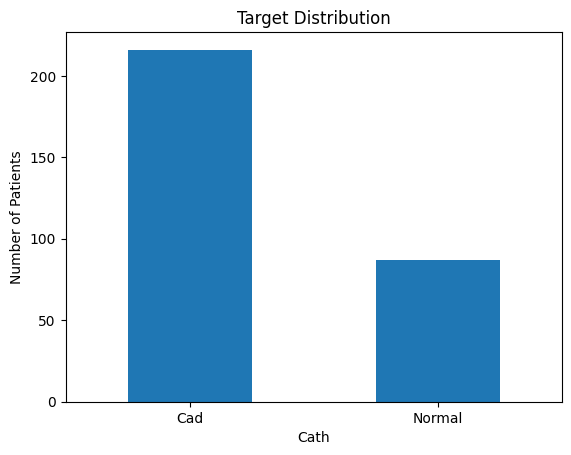

In [6]:
df["Cath"].value_counts().plot(kind="bar")

plt.title("Target Distribution")
plt.xlabel("Cath")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()


### Target distribution note

The dataset contains **216 CAD patients and 87 Normal patients**, corresponding to approximately **71% CAD and 29% Normal**.

This represents a moderate class imbalance. Later model evaluation should therefore not rely only on accuracy; metrics such as sensitivity, specificity, ROC-AUC, PR-AUC, PPV and NPV will also be important.


## 4. Data quality checks

Before analysing relationships with CAD, we check:

- missing values,
- duplicate rows,
- number of unique values,
- data types.

These checks help identify coding problems, suspicious variables, and variables that may need different treatment later.


In [7]:
print("Duplicate rows:", df.duplicated().sum())

missing = df.isna().sum().sort_values(ascending=False)
print("\nMissing values:")
display(missing.to_frame("missing_count"))

print("\nColumn types and cardinality:")
feature_overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "missing": df.isna().sum()
})
display(feature_overview)


Duplicate rows: 0

Missing values:


,missing_count
Age,0
Weight,0
Length,0
Sex,0
BMI,0
DM,0
HTN,0
Current Smoker,0
EX-Smoker,0
FH,0



Column types and cardinality:


,dtype,n_unique,missing
Age,int64,46,0
Weight,int64,54,0
Length,int64,44,0
Sex,object,2,0
BMI,float64,262,0
DM,int64,2,0
HTN,int64,2,0
Current Smoker,int64,2,0
EX-Smoker,int64,2,0
FH,int64,2,0


## 5. Semantic feature typing

A variable being stored as `int64` does **not** automatically mean that it is continuous.

For example:

- `DM = 0/1` is a binary clinical variable,
- `Age` is continuous,
- `Function Class = 0/1/2/3` is a low-cardinality ordered/coded variable,
- `Sex` and `VHD` are categorical variables.

For this reason, variables are grouped according to their clinical meaning rather than only their pandas dtype.


In [8]:
# Binary numeric variables (0/1)
binary_numeric = [
    "DM",
    "HTN",
    "Current Smoker",
    "EX-Smoker",
    "FH",
    "Edema",
    "Typical Chest Pain",
    "Q Wave",
    "St Elevation",
    "St Depression",
    "Tinversion"
]

# Low-cardinality numeric variables.
# Their exact interpretation should be confirmed from the dataset documentation.
low_cardinality_numeric = [
    "Function Class",
    "Region RWMA"
]

# Continuous variables grouped by clinical domain
continuous_groups = {
    "Demographic_Anthropometric": [
        "Age",
        "Weight",
        "Length",
        "BMI"
    ],

    "Hemodynamic_Vitals": [
        "BP",
        "PR"
    ],

    "Laboratory_Metabolic": [
        "FBS",
        "CR",
        "TG",
        "LDL",
        "HDL",
        "BUN",
        "ESR",
        "HB",
        "K",
        "Na",
        "WBC",
        "Lymph",
        "Neut",
        "PLT"
    ],

    "Cardiac_Function_Imaging": [
        "EF-TTE"
    ]
}

# Object/categorical variables grouped by clinical domain
categorical_groups = {
    "Demographic_Risk_History": [
        "Sex",
        "Obesity",
        "CRF",
        "CVA",
        "Airway disease",
        "Thyroid Disease",
        "CHF",
        "DLP"
    ],

    "Physical_Examination": [
        "Weak Peripheral Pulse",
        "Lung rales",
        "Systolic Murmur",
        "Diastolic Murmur"
    ],

    "Symptoms": [
        "Dyspnea",
        "Atypical",
        "Nonanginal",
        "Exertional CP",
        "LowTH Ang"
    ],

    "ECG_Categorical": [
        "LVH",
        "Poor R Progression",
        "BBB"
    ],

    "Valvular_Heart_Disease": [
        "VHD"
    ]
}

continuous_cols = [
    col
    for cols in continuous_groups.values()
    for col in cols
]

categorical_cols = [
    col
    for cols in categorical_groups.values()
    for col in cols
]

print("Binary numeric variables:", len(binary_numeric))
print(binary_numeric)

print("\nLow-cardinality numeric variables:", len(low_cardinality_numeric))
print(low_cardinality_numeric)

print("\nContinuous variables:", len(continuous_cols))
print(continuous_cols)

print("\nCategorical variables:", len(categorical_cols))
print(categorical_cols)


Binary numeric variables: 11
['DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH', 'Edema', 'Typical Chest Pain', 'Q Wave', 'St Elevation', 'St Depression', 'Tinversion']

Low-cardinality numeric variables: 2
['Function Class', 'Region RWMA']

Continuous variables: 21
['Age', 'Weight', 'Length', 'BMI', 'BP', 'PR', 'FBS', 'CR', 'TG', 'LDL', 'HDL', 'BUN', 'ESR', 'HB', 'K', 'Na', 'WBC', 'Lymph', 'Neut', 'PLT', 'EF-TTE']

Categorical variables: 21
['Sex', 'Obesity', 'CRF', 'CVA', 'Airway disease', 'Thyroid Disease', 'CHF', 'DLP', 'Weak Peripheral Pulse', 'Lung rales', 'Systolic Murmur', 'Diastolic Murmur', 'Dyspnea', 'Atypical', 'Nonanginal', 'Exertional CP', 'LowTH Ang', 'LVH', 'Poor R Progression', 'BBB', 'VHD']


### Feature coverage check

This cell verifies that every predictor has been assigned to exactly one working group.  
If `Unassigned features` is not empty, the feature typing needs to be corrected before continuing.


In [9]:
all_predictors = set(df.columns) - {"Cath"}

assigned_features = (
    binary_numeric
    + low_cardinality_numeric
    + continuous_cols
    + categorical_cols
)

assigned_set = set(assigned_features)

unassigned = sorted(all_predictors - assigned_set)

duplicate_assignments = sorted({
    col for col in assigned_features
    if assigned_features.count(col) > 1
})

print("Total predictors:", len(all_predictors))
print("Assigned predictors:", len(assigned_set))
print("Unassigned features:", unassigned)
print("Features assigned more than once:", duplicate_assignments)


Total predictors: 55
Assigned predictors: 55
Unassigned features: []
Features assigned more than once: []


## 6. Inspect low-cardinality numerical variables

This is a quick sanity check showing why some integer columns should not automatically be treated as continuous variables.


In [10]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in numeric_columns:
    if col != "Cath" and df[col].nunique() <= 5:
        print(col, df[col].unique())


DM [0 1]
HTN [1 0]
Current Smoker [1 0]
EX-Smoker [0 1]
FH [0 1]
Edema [0 1]
Typical Chest Pain [0 1]
Function Class [0 3 2 1]
Q Wave [0 1]
St Elevation [0 1]
St Depression [1 0]
Tinversion [1 0]
Region RWMA [0 4 2 3 1]


## 7. Continuous feature EDA

Continuous features are inspected by clinical group.

For each variable we compare CAD and Normal patients using:

- descriptive statistics,
- boxplots,
- distribution plots.

At this point, plots are used only for exploratory interpretation. Statistical significance and effect sizes will be added in the next stage.



============ Demographic_Anthropometric ============

--- Age ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,61.250000,61.5,9.878918,36,86
Normal,87,53.057471,52.0,9.320341,30,79


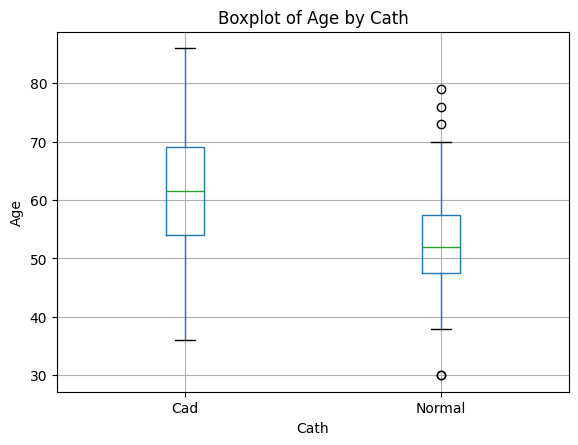


--- Weight ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,73.324074,73.0,11.839884,48,120
Normal,87,75.091954,75.0,12.324708,48,108


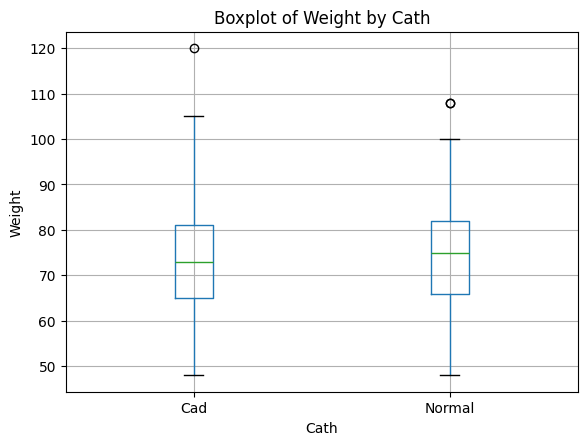


--- Length ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,164.722222,165.0,9.233743,144,187
Normal,87,164.701149,165.0,9.611179,140,188


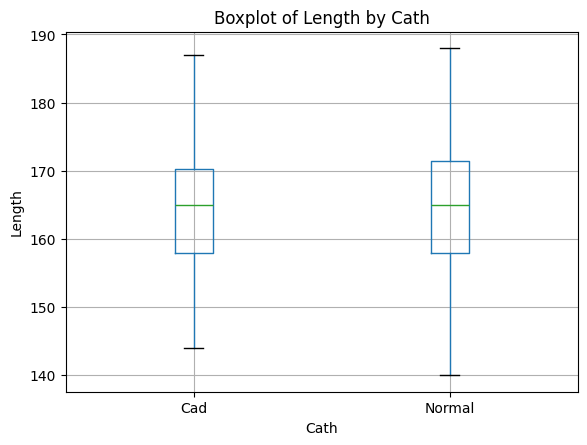


--- BMI ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,27.045279,26.619898,3.949441,18.365473,40.900658
Normal,87,27.752487,27.005131,4.431917,18.115413,37.370242


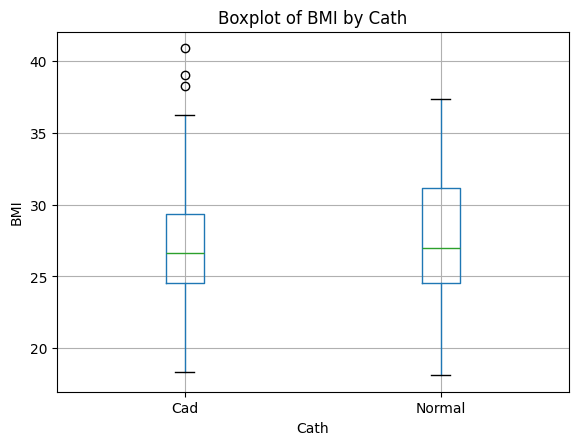


============ Hemodynamic_Vitals ============

--- BP ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,132.407407,130.0,18.476402,90,190
Normal,87,122.471264,120.0,18.297820,90,180


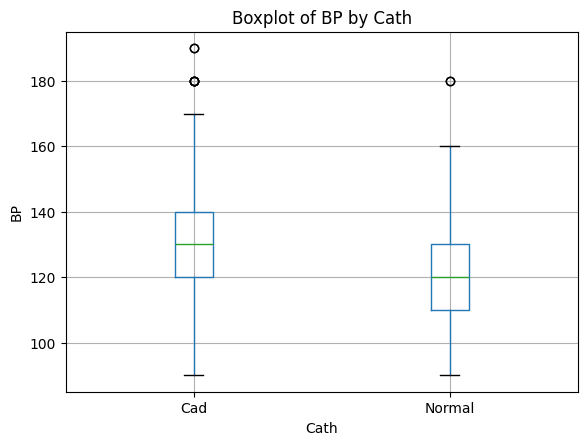


--- PR ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,76.092593,74.0,9.070306,50,110
Normal,87,72.781609,70.0,8.081597,50,100


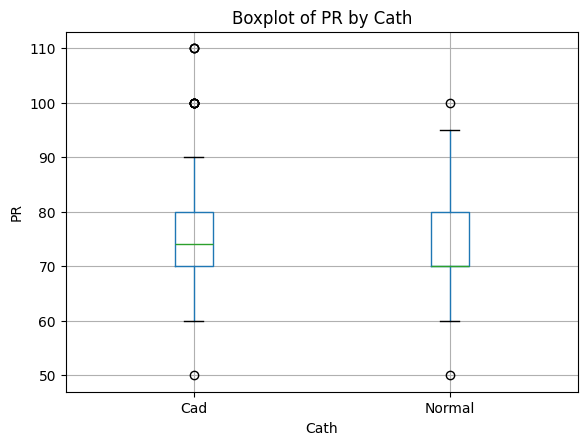


============ Laboratory_Metabolic ============

--- FBS ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,125.967593,103.0,56.255016,62,400
Normal,87,102.344828,92.0,34.793018,65,300


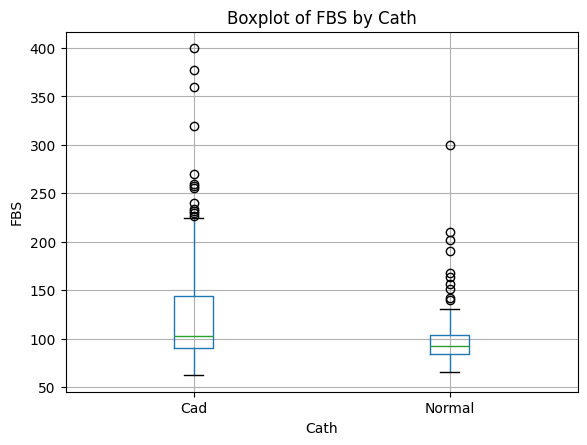


--- CR ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,1.070139,1.0,0.288701,0.5,2.2
Normal,87,1.019540,1.0,0.187294,0.6,1.6


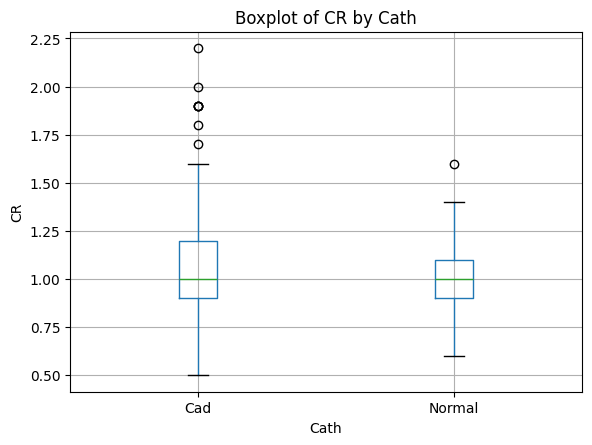


--- TG ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,159.069444,130.0,104.547396,50,1050
Normal,87,128.678161,110.0,75.539993,37,450


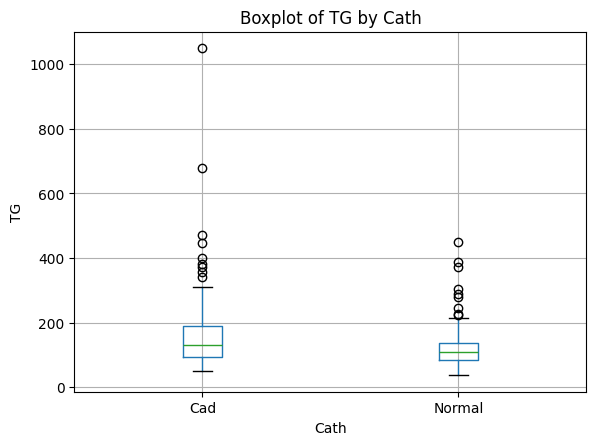


--- LDL ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,104.115741,100.0,35.460171,30,213
Normal,87,105.954023,101.0,35.409205,18,232


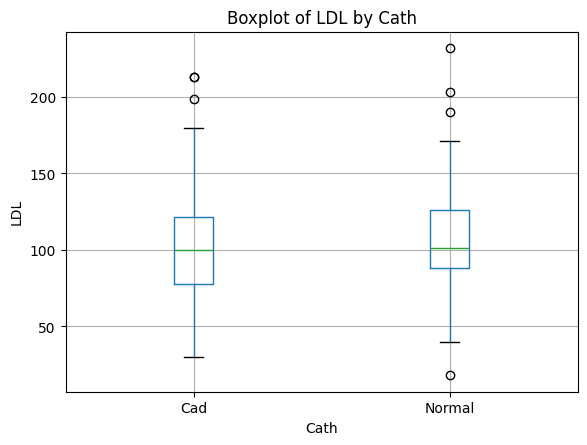


--- HDL ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,39.949074,39.0,10.130874,18.0,111.0
Normal,87,40.941379,42.0,11.585733,15.9,83.0


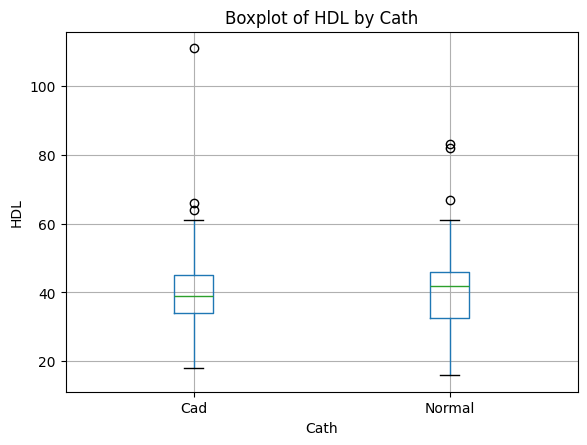


--- BUN ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,17.893519,16.0,7.232533,8,52
Normal,87,16.528736,15.0,6.150892,6,41


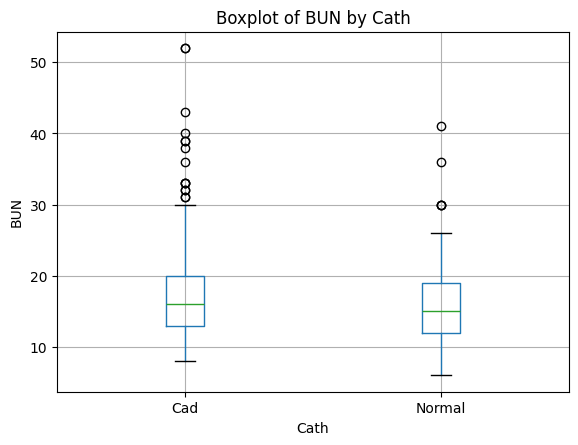


--- ESR ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,21.263889,16.0,16.430539,1,90
Normal,87,14.988506,12.0,13.731219,1,76


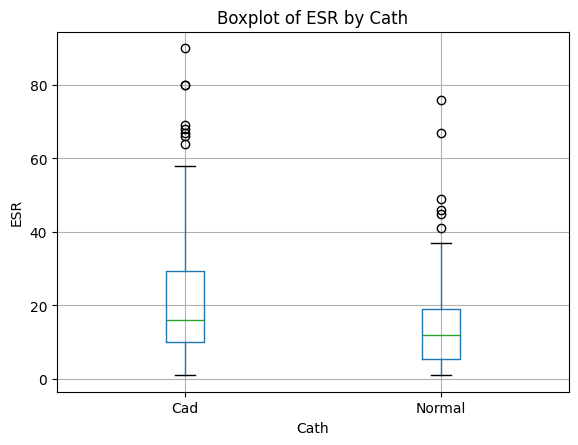


--- HB ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,13.110185,13.1,1.649577,8.9,17.6
Normal,87,13.260920,13.4,1.512764,9.0,17.5


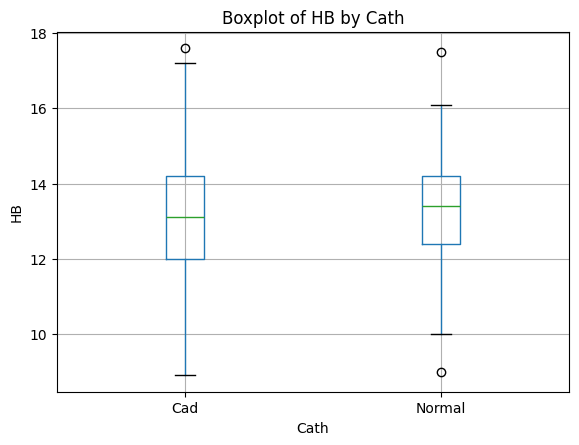


--- K ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,4.283333,4.3,0.475737,3.1,6.6
Normal,87,4.100000,4.1,0.383679,3.0,5.2


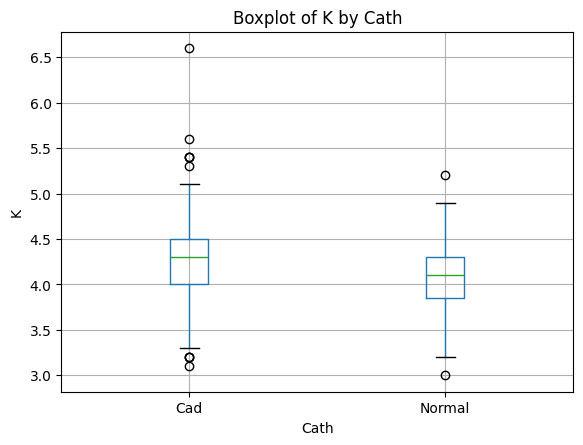


--- Na ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,140.791667,141.0,3.965916,128,156
Normal,87,141.505747,141.0,3.351062,131,153


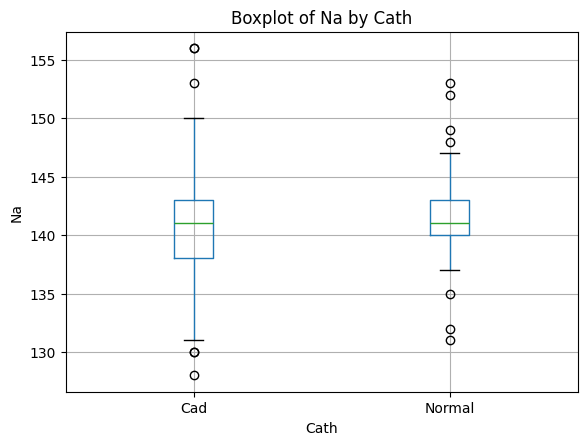


--- WBC ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,7670.370370,7150.0,2520.474642,3700,18000
Normal,87,7293.103448,7100.0,2115.325754,3800,17800


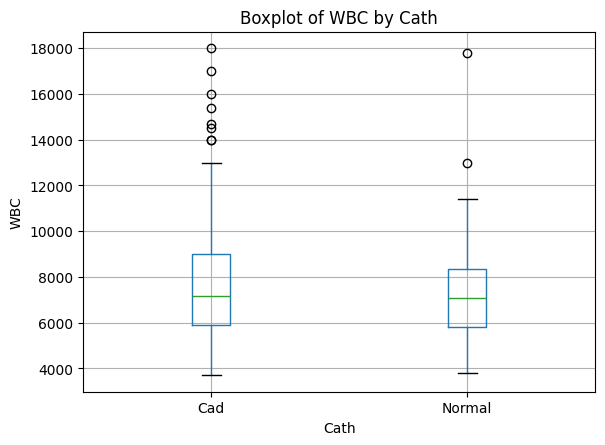


--- Lymph ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,31.597222,31.5,10.054724,7,60
Normal,87,34.390805,34.0,9.532510,9,60


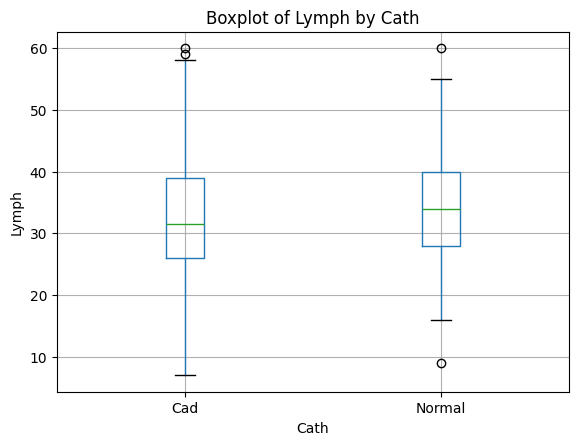


--- Neut ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,60.949074,60.0,10.239558,33,86
Normal,87,58.160920,58.0,9.816779,32,89


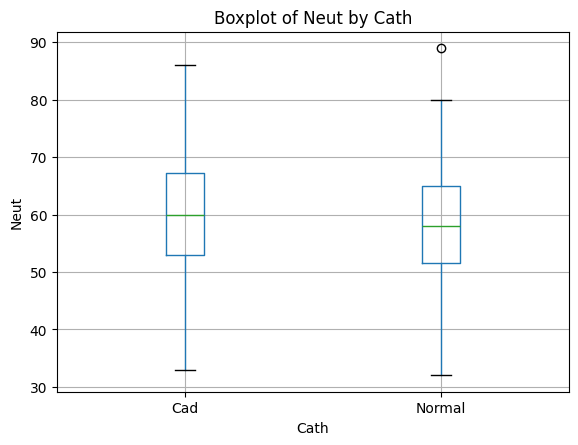


--- PLT ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,217.833333,208.0,53.232618,25,410
Normal,87,230.563218,217.0,76.016170,129,742


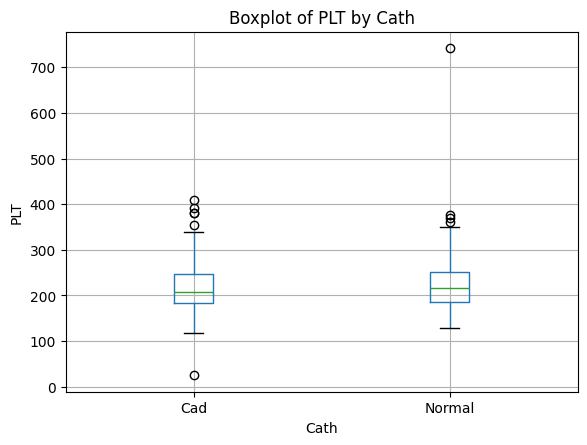


============ Cardiac_Function_Imaging ============

--- EF-TTE ---


,count,mean,median,std,min,max
Cath,,,,,,
Cad,216,45.907407,45.5,8.943790,15,60
Normal,87,50.517241,55.0,8.034608,15,60


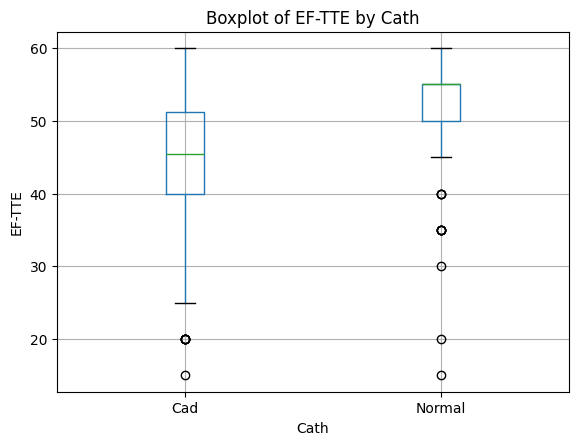

In [11]:
for group_name, columns in continuous_groups.items():

    print(f"\n{'=' * 12} {group_name} {'=' * 12}")

    for col in columns:

        if col not in df.columns:
            print(f"Missing column: {col}")
            continue

        print(f"\n--- {col} ---")

        summary = (
            df.groupby("Cath")[col]
            .agg(["count", "mean", "median", "std", "min", "max"])
        )

        display(summary)

        df.boxplot(column=col, by="Cath")
        plt.title(f"Boxplot of {col} by Cath")
        plt.suptitle("")
        plt.xlabel("Cath")
        plt.ylabel(col)
        plt.show()


### Interpretation of the continuous boxplots examined so far

From the variables inspected initially:

- **Age:** CAD patients show a noticeably higher median age and clearer separation from the Normal group.
- **Weight:** substantial overlap is present between CAD and Normal patients.
- **Length:** the distributions appear very similar between groups.
- **BMI:** substantial overlap is present and the medians are close.
- **BP:** CAD patients appear to have a moderately higher central tendency.
- **PR:** the two distributions overlap strongly.

These observations are **univariate and exploratory**. A variable with weak visual separation may still contribute useful information in combination with other predictors, so no feature is removed based on these plots alone.


## 8. Continuous distributions

Histograms are generated **only for continuous variables**.  
Binary 0/1 variables are intentionally excluded from this section.



============ Demographic_Anthropometric ============


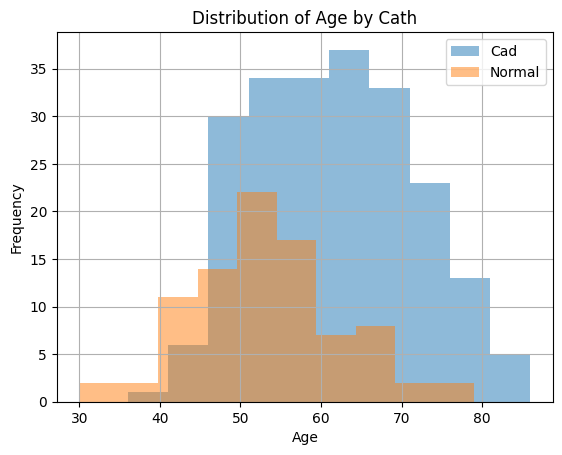

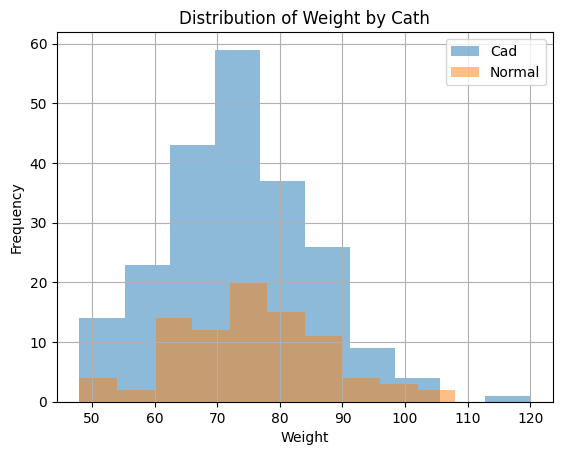

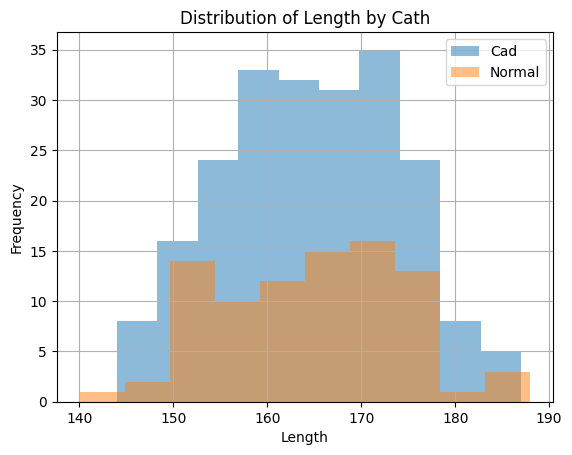

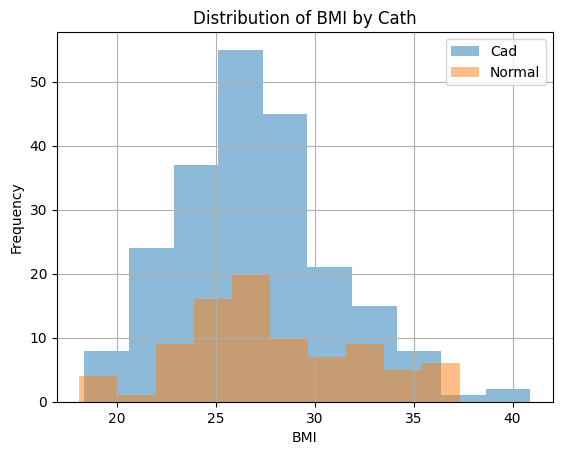


============ Hemodynamic_Vitals ============


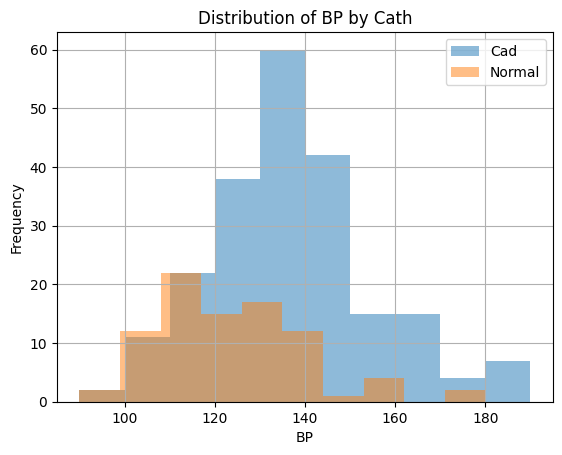

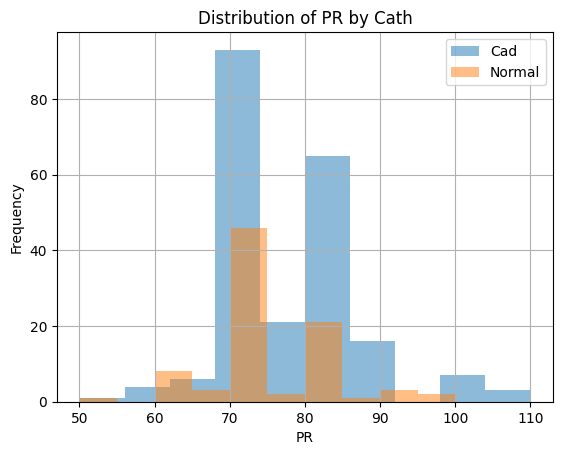


============ Laboratory_Metabolic ============


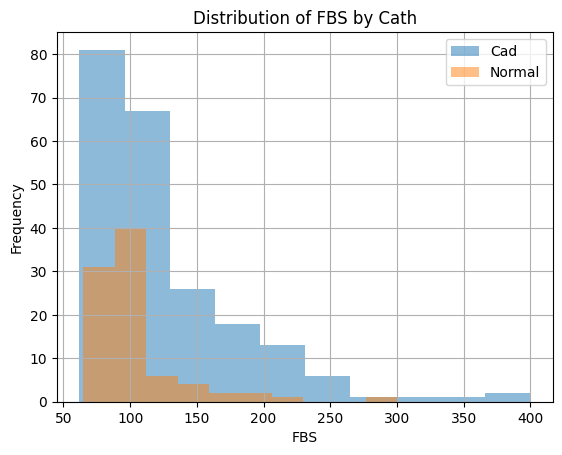

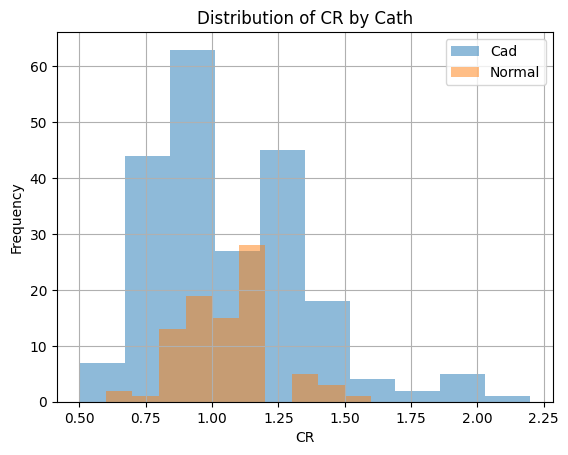

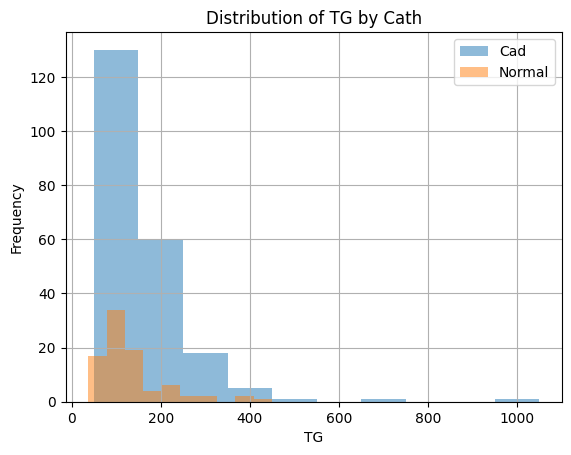

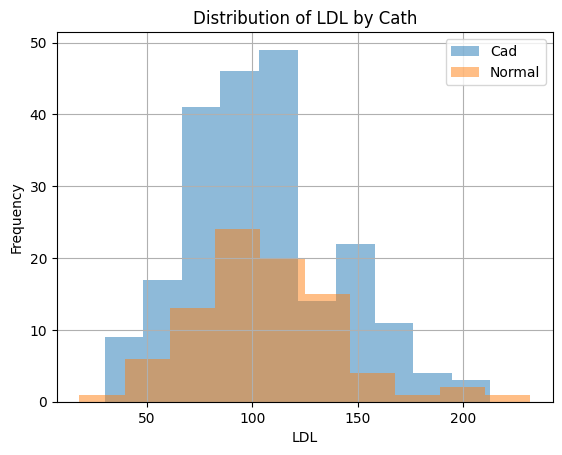

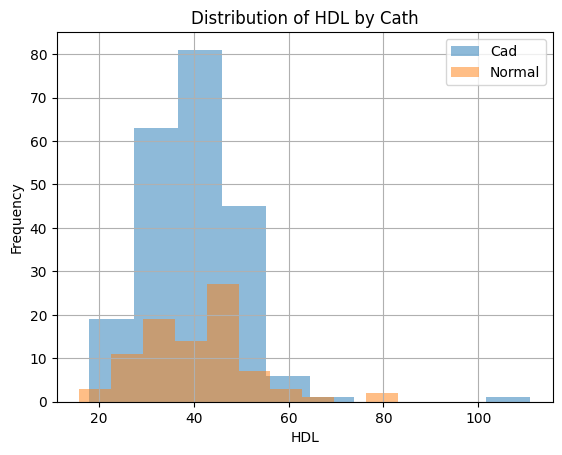

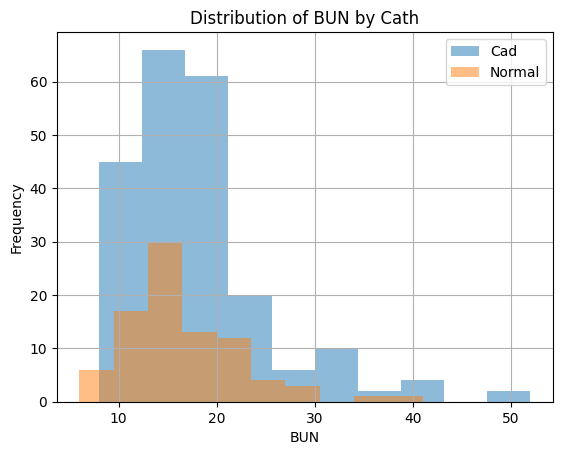

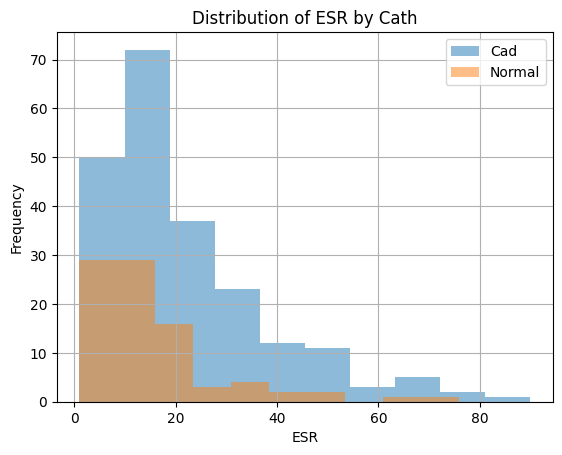

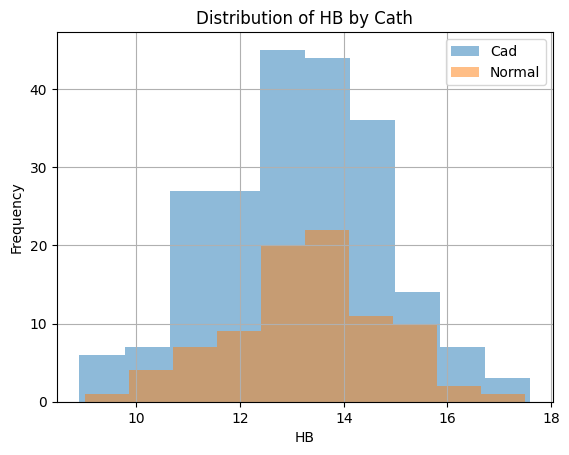

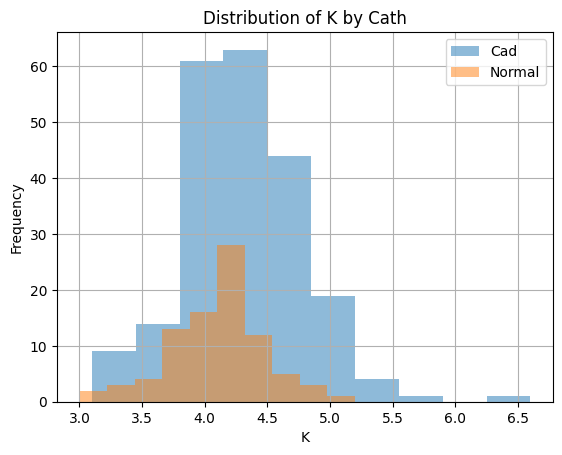

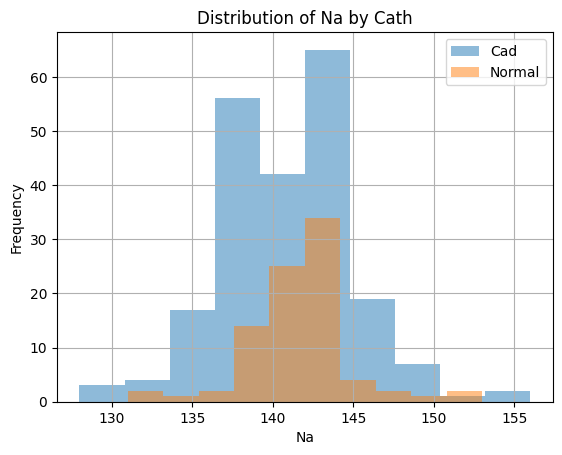

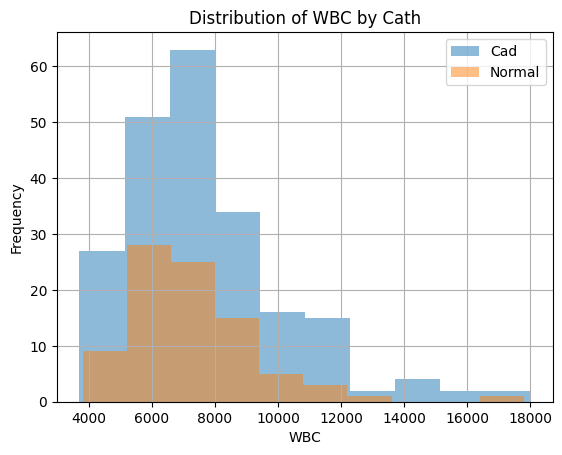

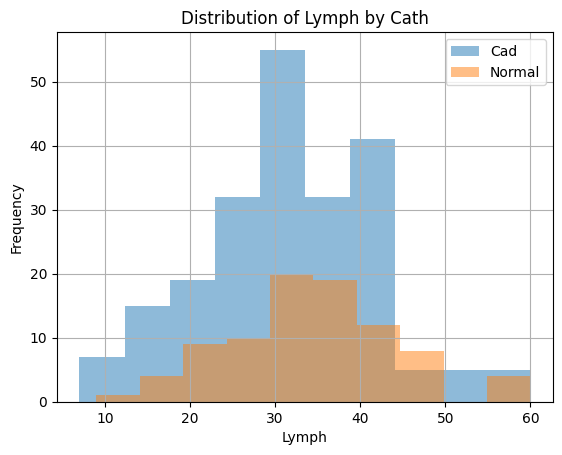

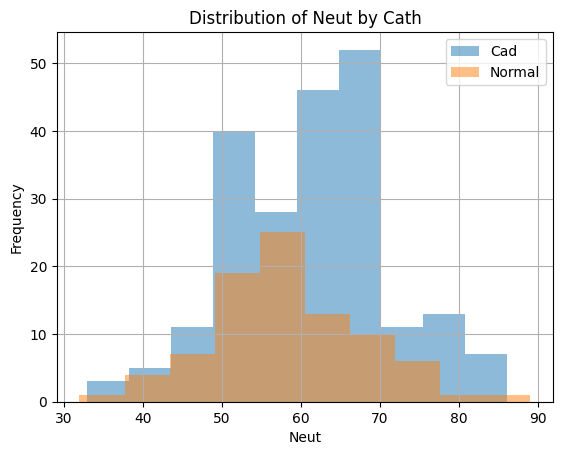

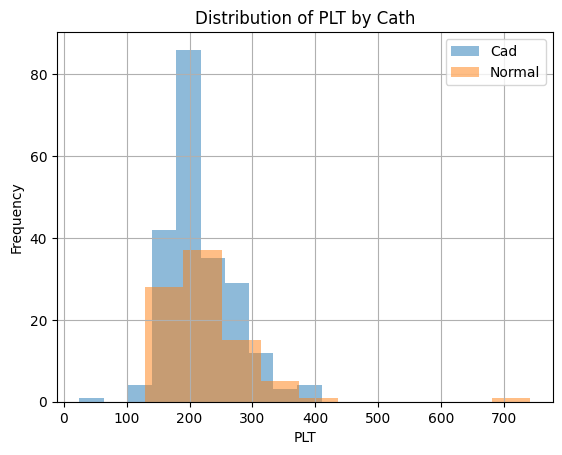


============ Cardiac_Function_Imaging ============


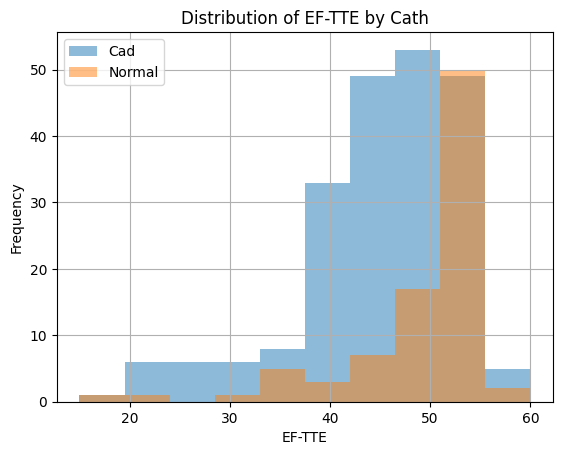

In [12]:
for group_name, columns in continuous_groups.items():

    print(f"\n{'=' * 12} {group_name} {'=' * 12}")

    for col in columns:

        if col not in df.columns:
            continue

        plt.figure()

        df.loc[df["Cath"] == "Cad", col].hist(
            alpha=0.5,
            label="Cad"
        )

        df.loc[df["Cath"] == "Normal", col].hist(
            alpha=0.5,
            label="Normal"
        )

        plt.title(f"Distribution of {col} by Cath")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.legend()
        plt.show()


## 9. First binary feature example — Diabetes Mellitus

For binary variables, the question is different from continuous variables:

> Does the presence of a binary clinical characteristic correspond to a different CAD proportion?

`DM` is used as the first example.


Cath,Cad,Normal
DM,,
0,0.638498,0.361502
1,0.888889,0.111111


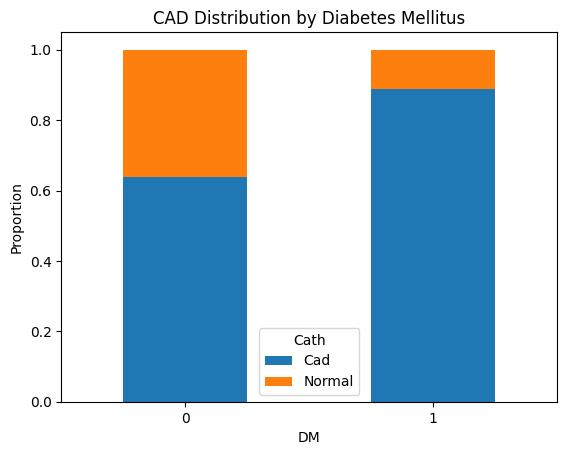

In [13]:
dm_rates = pd.crosstab(
    df["DM"],
    df["Cath"],
    normalize="index"
)

display(dm_rates)

dm_rates.plot(kind="bar", stacked=True)

plt.title("CAD Distribution by Diabetes Mellitus")
plt.xlabel("DM")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()


### DM interpretation

In this dataset:

- among patients without DM, approximately **63.8%** have CAD,
- among patients with DM, approximately **88.9%** have CAD.

This suggests a strong observed association between diabetes and CAD status in this sample.  
A statistical test and effect-size estimate are used below to quantify this association.


In [14]:
from scipy.stats import chi2_contingency
from scipy.stats.contingency import odds_ratio

dm_table = pd.crosstab(df["DM"], df["Cath"])

chi2, p_value, dof, expected = chi2_contingency(dm_table)

print("Observed contingency table:")
display(dm_table)

print("Chi-square:", chi2)
print("p-value:", p_value)

# Odds ratio using the 2x2 table
# Rows: DM 0/1, Columns: Cad/Normal
a = dm_table.loc[1, "Cad"]
b = dm_table.loc[1, "Normal"]
c = dm_table.loc[0, "Cad"]
d = dm_table.loc[0, "Normal"]

or_value = (a * d) / (b * c)

print("Odds Ratio:", or_value)


Observed contingency table:


Cath,Cad,Normal
DM,,
0,136,77
1,80,10


Chi-square: 18.174948228643895
p-value: 2.0151216696088066e-05
Odds Ratio: 4.529411764705882


### Interpretation of the DM association

The observed DM × Cath table gives a very small p-value, indicating evidence against independence between DM and CAD status in this dataset.

The estimated odds ratio is approximately **4.5**, meaning that the observed odds of CAD are substantially higher among patients with DM than among patients without DM.

Important:

- this is an **association**, not proof of causation;
- statistical significance is not the same as clinical importance;
- this univariate result does not determine whether DM will be selected by the final multivariate model or Genetic Algorithm.


## 10. Where the EDA currently stops

At this point the notebook has established:

- dataset structure and target definition,
- class distribution,
- data quality checks,
- complete working feature categorisation,
- continuous-variable exploratory analysis,
- the first binary-variable association analysis.

### Next planned EDA steps

The next additions should be:

1. automated binary/categorical association table for all binary variables,
2. continuous-variable statistical comparison table,
3. effect sizes and confidence intervals,
4. correlation and redundancy analysis,
5. outlier review,
6. PCA as an exploratory representation,
7. clustering as an exploratory patient-phenotype analysis.

Only after the EDA is complete should the project move to:

- feature engineering,
- preprocessing,
- baseline supervised models,
- Genetic Algorithm feature selection,
- nested cross-validation,
- calibration and explainability.

### Relationship with Genetic Algorithm feature selection

EDA and the Genetic Algorithm have different roles:

- **EDA** characterises individual variables, clinical associations, distributions, data quality and redundancy.
- **Genetic Algorithm feature selection** later searches for a useful **multivariate subset of predictors**.

Features should therefore **not** be removed simply because they have a high univariate p-value or weak visual separation.


In [15]:
from scipy.stats import chi2_contingency, fisher_exact
import numpy as np

In [16]:
binary_cols = []

for col in df.columns:
    if col == "Cath":
        continue
    
    unique_values = set(df[col].dropna().unique())
    if unique_values.issubset({0,1}):
        binary_cols.append(col)
        
print(binary_cols)        

['DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH', 'Edema', 'Typical Chest Pain', 'Q Wave', 'St Elevation', 'St Depression', 'Tinversion']


In [17]:
results = []

for col in binary_cols:

    table = pd.crosstab(df[col], df["Cath"])

    if 0 not in table.index or 1 not in table.index:
        continue

    # Counts
    cad_0 = table.loc[0, "Cad"]
    normal_0 = table.loc[0, "Normal"]

    cad_1 = table.loc[1, "Cad"]
    normal_1 = table.loc[1, "Normal"]

    # CAD rates
    cad_rate_0 = cad_0 / (cad_0 + normal_0)
    cad_rate_1 = cad_1 / (cad_1 + normal_1)

    # Odds Ratio
    # μικρό correction για περίπτωση zero counts
    a = cad_1 + 0.5
    b = normal_1 + 0.5
    c = cad_0 + 0.5
    d = normal_0 + 0.5

    odds_ratio = (a * d) / (b * c)

    # Chi-square + expected frequencies
    chi2, p_chi, dof, expected = chi2_contingency(table)

    # Αν κάποιο expected count < 5 → Fisher
    if (expected < 5).any():
        _, p_value = fisher_exact(table)
        test_used = "Fisher"
    else:
        p_value = p_chi
        test_used = "Chi-square"

    results.append({
        "Feature": col,
        "CAD rate 0": cad_rate_0,
        "CAD rate 1": cad_rate_1,
        "Difference": cad_rate_1 - cad_rate_0,
        "Odds Ratio": odds_ratio,
        "p-value": p_value,
        "Test": test_used
    })

In [18]:
binary_results = pd.DataFrame(results).sort_values(by="p-value")
binary_results

,Feature,CAD rate 0,CAD rate 1,Difference,Odds Ratio,p-value,Test
6,Typical Chest Pain,0.446043,0.939024,0.492981,18.245714,1.120876e-20,Chi-square
1,HTN,0.556452,0.821229,0.264777,3.624239,1.061399e-06,Chi-square
0,DM,0.638498,0.888889,0.250391,4.352869,2.015122e-05,Chi-square
10,Tinversion,0.643192,0.877778,0.234585,3.846166,6.738843e-05,Chi-square
7,Q Wave,0.696864,1.000000,0.303136,14.401496,7.787611e-03,Fisher
8,St Elevation,0.698962,1.000000,0.301038,12.530864,1.271483e-02,Fisher
9,St Depression,0.676724,0.830986,0.154262,2.281778,1.807318e-02,Chi-square
2,Current Smoker,0.695833,0.777778,0.081944,1.497993,2.614282e-01,Chi-square
5,Edema,0.707904,0.833333,0.125430,1.738983,5.193527e-01,Fisher
4,FH,0.705882,0.750000,0.044118,1.221385,6.556712e-01,Chi-square


In [20]:
numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print(numerical_cols)

['Age', 'Weight', 'Length', 'BMI', 'DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH', 'BP', 'PR', 'Edema', 'Typical Chest Pain', 'Function Class', 'Q Wave', 'St Elevation', 'St Depression', 'Tinversion', 'FBS', 'CR', 'TG', 'LDL', 'HDL', 'BUN', 'ESR', 'HB', 'K', 'Na', 'WBC', 'Lymph', 'Neut', 'PLT', 'EF-TTE', 'Region RWMA']


In [21]:
continuous_cols = []

for col in numerical_cols:
    if df[col].nunique() > 5:
        continuous_cols.append(col)

print(continuous_cols)

['Age', 'Weight', 'Length', 'BMI', 'BP', 'PR', 'FBS', 'CR', 'TG', 'LDL', 'HDL', 'BUN', 'ESR', 'HB', 'K', 'Na', 'WBC', 'Lymph', 'Neut', 'PLT', 'EF-TTE']


In [22]:
from scipy.stats import (
    shapiro,
    ttest_ind,
    mannwhitneyu
)

In [26]:
continuous_results = []

for col in continuous_cols:

    cad = df.loc[df["Cath"] == "Cad", col].dropna()
    normal = df.loc[df["Cath"] == "Normal", col].dropna()

    # Descriptive statistics
    cad_mean = cad.mean()
    normal_mean = normal.mean()

    cad_median = cad.median()
    normal_median = normal.median()

    # Normality test
    p_cad_normality = shapiro(cad).pvalue
    p_normal_normality = shapiro(normal).pvalue

    # Αν και τα δύο groups είναι περίπου normal
    if p_cad_normality > 0.05 and p_normal_normality > 0.05:

        stat, p_value = ttest_ind(
            cad,
            normal,
            equal_var=False
        )

        test_used = "Welch t-test"

        # Cohen's d
        pooled_std = np.sqrt(
            (
                cad.std(ddof=1) ** 2
                +
                normal.std(ddof=1) ** 2
            ) / 2
        )

        effect_size = (
            cad_mean - normal_mean
        ) / pooled_std

        effect_name = "Cohen's d"

    else:

        stat, p_value = mannwhitneyu(
            cad,
            normal,
            alternative="two-sided"
        )

        test_used = "Mann-Whitney"

        # Rank-biserial correlation
        n1 = len(cad)
        n2 = len(normal)

        effect_size = (2 * stat) / (n1 * n2) - 1

        effect_name = "Rank-biserial"

    continuous_results.append({
        "Feature": col,
        "CAD mean": cad_mean,
        "Normal mean": normal_mean,
        "CAD median": cad_median,
        "Normal median": normal_median,
        "Effect size": effect_size,
        "Effect type": effect_name,
        "p-value": p_value,
        "Test": test_used
    })

In [27]:
continuous_results = pd.DataFrame(
    continuous_results
)

continuous_results = (
    continuous_results
    .sort_values("p-value")
    .reset_index(drop=True)
)

continuous_results

,Feature,CAD mean,Normal mean,CAD median,Normal median,Effect size,Effect type,p-value,Test
0,Age,61.250000,53.057471,61.500000,52.000000,0.853060,Cohen's d,1.731053e-10,Welch t-test
1,EF-TTE,45.907407,50.517241,45.500000,55.000000,-0.373936,Rank-biserial,1.627515e-07,Mann-Whitney
2,BP,132.407407,122.471264,130.000000,120.000000,0.322797,Rank-biserial,8.398980e-06,Mann-Whitney
3,FBS,125.967593,102.344828,103.000000,92.000000,0.302522,Rank-biserial,3.780629e-05,Mann-Whitney
4,ESR,21.263889,14.988506,16.000000,12.000000,0.267827,Rank-biserial,2.636357e-04,Mann-Whitney
5,TG,159.069444,128.678161,130.000000,110.000000,0.236005,Rank-biserial,1.311122e-03,Mann-Whitney
6,K,4.283333,4.100000,4.300000,4.100000,0.229353,Rank-biserial,1.735896e-03,Mann-Whitney
7,PR,76.092593,72.781609,74.000000,70.000000,0.204768,Rank-biserial,3.248365e-03,Mann-Whitney
8,Lymph,31.597222,34.390805,31.500000,34.000000,-0.285144,Cohen's d,2.439393e-02,Welch t-test
9,Neut,60.949074,58.160920,60.000000,58.000000,0.277971,Cohen's d,2.855090e-02,Welch t-test


In [28]:
continuous_results.style.format({
    "CAD mean": "{:.2f}",
    "Normal mean": "{:.2f}",
    "CAD median": "{:.2f}",
    "Normal median": "{:.2f}",
    "Effect size": "{:.2f}",
    "p-value": "{:.4g}"
})

,Feature,CAD mean,Normal mean,CAD median,Normal median,Effect size,Effect type,p-value,Test
0,Age,61.25,53.06,61.50,52.00,0.85,Cohen's d,1.731e-10,Welch t-test
1,EF-TTE,45.91,50.52,45.50,55.00,-0.37,Rank-biserial,1.628e-07,Mann-Whitney
2,BP,132.41,122.47,130.00,120.00,0.32,Rank-biserial,8.399e-06,Mann-Whitney
3,FBS,125.97,102.34,103.00,92.00,0.30,Rank-biserial,3.781e-05,Mann-Whitney
4,ESR,21.26,14.99,16.00,12.00,0.27,Rank-biserial,0.0002636,Mann-Whitney
5,TG,159.07,128.68,130.00,110.00,0.24,Rank-biserial,0.001311,Mann-Whitney
6,K,4.28,4.10,4.30,4.10,0.23,Rank-biserial,0.001736,Mann-Whitney
7,PR,76.09,72.78,74.00,70.00,0.20,Rank-biserial,0.003248,Mann-Whitney
8,Lymph,31.60,34.39,31.50,34.00,-0.29,Cohen's d,0.02439,Welch t-test
9,Neut,60.95,58.16,60.00,58.00,0.28,Cohen's d,0.02855,Welch t-test


In [37]:
corr_matrix = df[continuous_cols].corr(method="spearman")

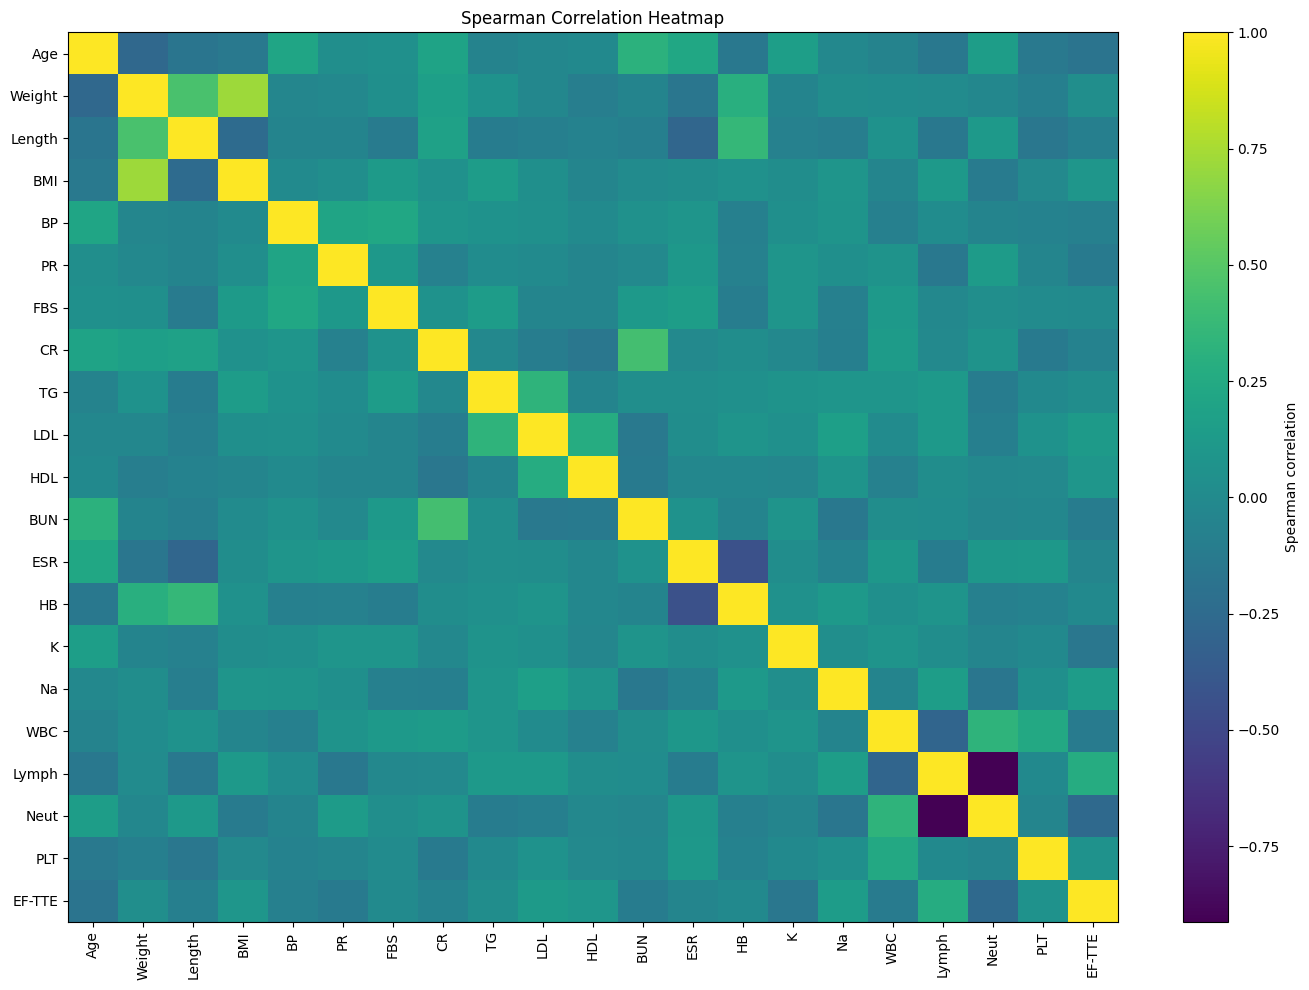

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

plt.imshow(
    corr_matrix,
    aspect="auto"
)

plt.colorbar(label="Spearman correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Spearman Correlation Heatmap")

plt.tight_layout()
plt.show()

In [40]:
strong_correlations = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        corr = corr_matrix.iloc[i, j]

        if abs(corr) >= 0.7:
            strong_correlations.append({
                "Feature 1": corr_matrix.columns[i],
                "Feature 2": corr_matrix.columns[j],
                "Correlation": corr
            })

strong_correlations = pd.DataFrame(strong_correlations)

strong_correlations = strong_correlations.sort_values(
    "Correlation",
    key=abs,
    ascending=False
)

strong_correlations

,Feature 1,Feature 2,Correlation
1,Lymph,Neut,-0.912341
0,Weight,BMI,0.719565


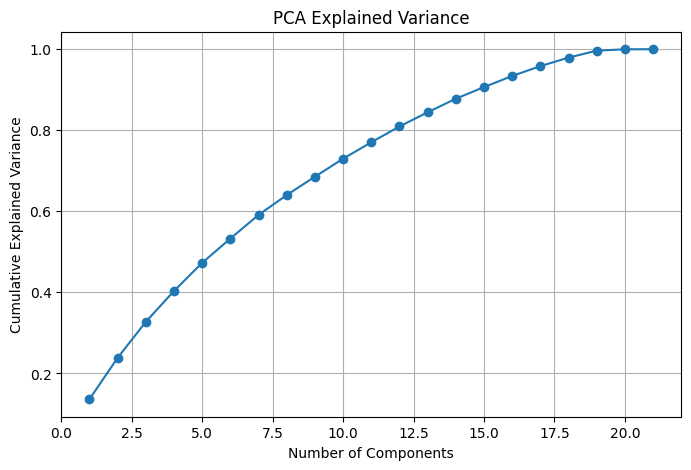

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_cont = df[continuous_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cont)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(explained_var) + 1),
    explained_var.cumsum(),
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

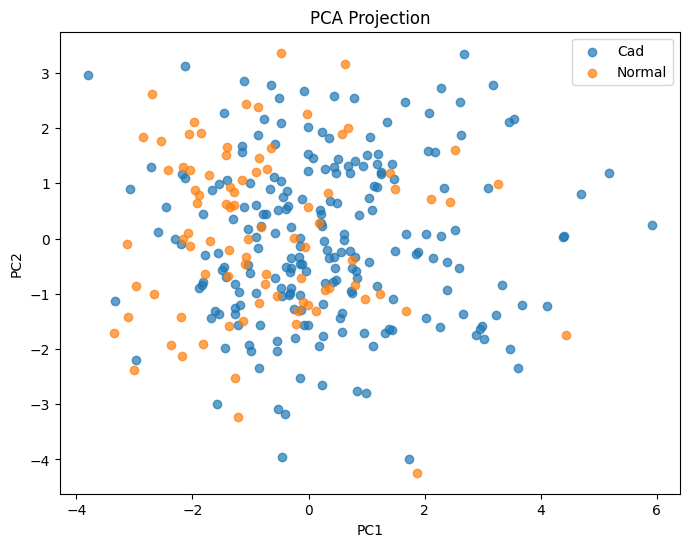

In [30]:
plt.figure(figsize=(8, 6))

for label in ["Cad", "Normal"]:
    mask = df["Cath"] == label

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=label,
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.legend()
plt.show()

In [31]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=continuous_cols,
    columns=[f"PC{i+1}" for i in range(len(continuous_cols))]
)

loadings[["PC1", "PC2"]].sort_values(
    "PC1",
    key=abs,
    ascending=False
)

,PC1,PC2
Neut,0.419782,0.248547
Lymph,-0.416398,-0.258471
Age,0.286839,-0.170620
WBC,0.281166,0.133976
ESR,0.255584,-0.245325
EF-TTE,-0.253309,-0.151262
BUN,0.234923,-0.020054
HB,-0.216207,0.364848
Weight,-0.200890,0.461405
BMI,-0.188958,0.110362


In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append({
        "k": k,
        "silhouette": score
    })

pd.DataFrame(scores)

,k,silhouette
0,2,0.109055
1,3,0.061667
2,4,0.062389
3,5,0.053278
4,6,0.053206


In [33]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

In [34]:
pd.crosstab(
    df["Cluster"],
    df["Cath"],
    normalize="index"
)

Cath,Cad,Normal
Cluster,,
0,0.870968,0.129032
1,0.722689,0.277311
2,0.622951,0.377049


In [35]:
cluster_profile = df.groupby("Cluster")[continuous_cols].mean()

cluster_profile

,Age,Weight,Length,BMI,BP,PR,FBS,CR,TG,LDL,...,BUN,ESR,HB,K,Na,WBC,Lymph,Neut,PLT,EF-TTE
Cluster,,,,,,,,,,,,,,,,,,,,,
0,64.758065,69.774194,166.225806,25.268124,128.548387,78.645161,143.064516,1.187903,135.258065,93.725806,...,21.193548,29.548387,12.566129,4.319355,139.096774,10046.774194,21.790323,71.403226,241.661290,40.645161
1,60.873950,68.142857,157.848739,27.479170,134.243697,75.857143,123.983193,0.987395,153.672269,115.302521,...,17.714286,20.655462,12.621849,4.265546,141.739496,6611.764706,36.663866,55.546218,220.521008,49.714286
2,53.991803,81.442623,170.647541,28.029522,125.491803,72.663934,102.368852,1.054918,154.762295,99.795082,...,15.418033,13.172131,13.970492,4.151639,141.237705,7226.229508,33.631148,58.918033,212.180328,48.155738


In [36]:
cluster_binary = df.groupby("Cluster")[binary_cols].mean()

cluster_binary

,DM,HTN,Current Smoker,EX-Smoker,FH,Edema,Typical Chest Pain,Q Wave,St Elevation,St Depression,Tinversion
Cluster,,,,,,,,,,,
0,0.483871,0.661290,0.177419,0.016129,0.129032,0.096774,0.564516,0.096774,0.080645,0.338710,0.322581
1,0.319328,0.697479,0.117647,0.016807,0.176471,0.033613,0.546218,0.025210,0.025210,0.260504,0.302521
2,0.180328,0.450820,0.311475,0.057377,0.155738,0.016393,0.524590,0.057377,0.049180,0.155738,0.278689


το να κρατησεςι ολες τι ςμεταβλτητες ζοριζει το μοντελο λογο της διαστατικοτητας 